In [3]:
# Step 1: Install the necessary libraries
# If you haven't already installed hmmlearn, you can do so using pip:
# pip install hmmlearn

import numpy as np
from hmmlearn.hmm import MultinomialHMM
import matplotlib.pyplot as plt

# Step 2: Generate synthetic sequential data
# Let's create a simple example with 2 hidden states (0 and 1) and 2 possible observations (0 and 1)

# Set a random seed for reproducibility
np.random.seed(42)

# Define the transition probabilities and emission probabilities for the HMM
# Transition matrix: P(state_t | state_(t-1))
transition_matrix = np.array([
    [0.7, 0.3],  # State 0 -> State 0, State 0 -> State 1
    [0.4, 0.6]   # State 1 -> State 0, State 1 -> State 1
])

# Emission matrix: P(observation_t | state_t)
emission_matrix = np.array([
    [0.9, 0.1],  # State 0 emits 0 with probability 0.9, 1 with probability 0.1
    [0.2, 0.8]   # State 1 emits 0 with probability 0.2, 1 with probability 0.8
])

# Initial state distribution
start_probabilities = np.array([0.6, 0.4])

# Define the length of the sequence
n_samples = 100

# Create the HMM
model = MultinomialHMM(n_components=2, random_state=42)
model.startprob_ = start_probabilities
model.transmat_ = transition_matrix
model.emissionprob_ = emission_matrix

# Generate the synthetic observation sequence (length = n_samples)
X, Z = model.sample(n_samples)  # X are the observations, Z are the hidden states

# Step 3: Fit the HMM model to the data
# Now let's fit an HMM to the data using the hmmlearn library
model_fit = MultinomialHMM(n_components=2, random_state=42)
model_fit.fit(X)

# Step 4: Predict the hidden states from the observations
hidden_states = model_fit.predict(X)

# Step 5: Visualize the results
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.title('Generated Observations')
plt.plot(X, label='Observations')
plt.xlabel('Time')
plt.ylabel('Observation Value')
plt.legend()

plt.subplot(2, 1, 2)
plt.title('Predicted Hidden States')
plt.plot(hidden_states, label='Hidden States', color='red')
plt.xlabel('Time')
plt.ylabel('Hidden State')
plt.legend()

plt.tight_layout()
plt.show()

# Step 6: Evaluate the performance (optional)
# You can compare the predicted hidden states with the true hidden states (Z) to check the model's accuracy
accuracy = np.sum(hidden_states == Z) / n_samples
print(f"Accuracy of hidden state prediction: {accuracy * 100:.2f}%")


MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


ValueError: n_trials must be set

In [2]:
pip install hmmlearn

  Obtaining dependency information for hmmlearn from https://files.pythonhosted.org/packages/92/57/24bd2359bf0f2a2514f7b53f0bca562f912ac4751e415756b9138970c5aa/hmmlearn-0.3.3-cp312-cp312-win_amd64.whl.metadata
   ---------------------------------------- 0.0/127.3 kB ? eta -:--:--
   --- ------------------------------------ 10.2/127.3 kB ? eta -:--:--
   --- ------------------------------------ 10.2/127.3 kB ? eta -:--:--
   ------ -------------------------------- 20.5/127.3 kB 217.9 kB/s eta 0:00:01
   ------------ -------------------------- 41.0/127.3 kB 279.3 kB/s eta 0:00:01
   ------------------------------------ - 122.9/127.3 kB 654.9 kB/s eta 0:00:01
   -------------------------------------- 127.3/127.3 kB 534.5 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: C:\Users\drtpr\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


Predicted hidden states: [0 0 0 0 0 0 0 0 0 0]


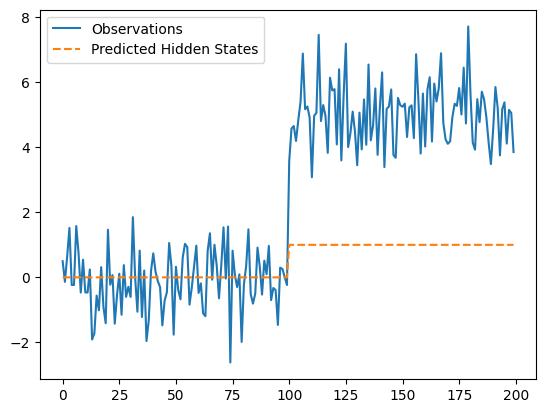

In [4]:
# Step 1: Install hmmlearn if you haven't already
# pip install hmmlearn

import numpy as np
from hmmlearn.hmm import GaussianHMM

# Example: Generating synthetic sequential data
np.random.seed(42)
X = np.concatenate([np.random.normal(0, 1, (100, 1)), np.random.normal(5, 1, (100, 1))])

# Reshaping the data as the model expects a 2D array: (n_samples, n_features)
X = X.reshape(-1, 1)

# Step 2: Create an HMM model
model = GaussianHMM(n_components=2, covariance_type="diag", random_state=42)

# Step 3: Fit the model to the data (no need for n_trials)
model.fit(X)

# Step 4: Predict the hidden states
hidden_states = model.predict(X)

# Print the predicted hidden states
print(f"Predicted hidden states: {hidden_states[:10]}")

# Step 5: Optionally, you can visualize the hidden states and observations
import matplotlib.pyplot as plt
plt.plot(X, label="Observations")
plt.plot(hidden_states, label="Predicted Hidden States", linestyle="--")
plt.legend()
plt.show()
